# P(white plays Rb5 by move N)

For each full move number N, what fraction of master-level games have seen white move a rook to b5 at or before move N?

This requires replaying every game with `python-chess`, so we use `chess_corpus.analysis.map_shards` to parallelize across all parquet shards.

Toggle `USE_FULL_CORPUS` to switch between the 100-game sample (instant) and the full ~900k-game corpus (~2 min on 8 cores).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from chess_corpus.analysis import map_shards, white_rook_to_b5

USE_FULL_CORPUS = False

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SHARD_DIR = ROOT / ("data/processed/games" if USE_FULL_CORPUS else "data/sample/games")
print(f"Reading shards from {SHARD_DIR}")

Reading shards from /Users/paul/pwsiegel/chess-move-stats/data/sample/games


## Compute per-game stats

`white_rook_to_b5` returns one row per game with the first full-move number on which white moved a rook to b5 (or `None`), plus the lowest material at any such moment.

In [2]:
per_game = pd.DataFrame(map_shards(white_rook_to_b5, shard_dir=SHARD_DIR))
print(f"games scanned: {len(per_game):,}")
print(f"games with white Rb5: {per_game['first_rb5_fullmove'].notna().sum():,}")
per_game.head()

games scanned: 100
games with white Rb5: 4


,first_rb5_fullmove,min_material_at_rb5,n_white_moves
0,NaN,NaN,41
1,NaN,NaN,35
2,NaN,NaN,27
3,NaN,NaN,23
4,NaN,NaN,27


## Build the CDF: P(Rb5 by move N)

Denominator is ALL games (not just games with ≥N moves) — so this is the unconditional probability that white plays Rb5 within the first N full moves. Games that end before N without an Rb5 are correctly counted as "didn't happen".

In [3]:
max_n = 80
n_total = len(per_game)
first = per_game["first_rb5_fullmove"].dropna().astype(int).values

ns = np.arange(1, max_n + 1)
counts = np.array([(first <= n).sum() for n in ns])
cdf = pd.DataFrame({"N": ns, "games_with_rb5_by_N": counts, "prob": counts / n_total})
cdf.tail(10)

,N,games_with_rb5_by_N,prob
70,71,4,0.04
71,72,4,0.04
72,73,4,0.04
73,74,4,0.04
74,75,4,0.04
75,76,4,0.04
76,77,4,0.04
77,78,4,0.04
78,79,4,0.04
79,80,4,0.04


## Plot

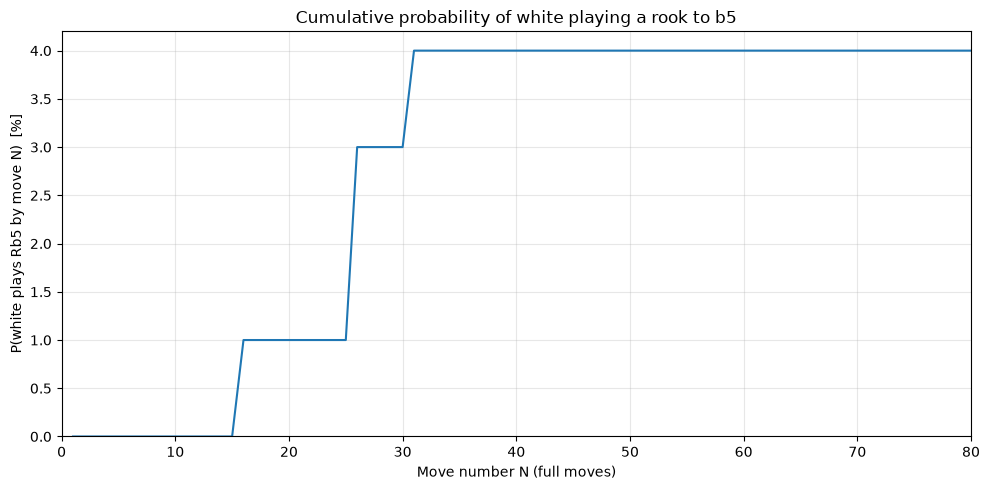

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cdf["N"], cdf["prob"] * 100)
ax.set_xlabel("Move number N (full moves)")
ax.set_ylabel("P(white plays Rb5 by move N)  [%]")
ax.set_title("Cumulative probability of white playing a rook to b5")
ax.grid(alpha=0.3)
ax.set_xlim(0, max_n)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()